In [263]:
using Revise, SciBmad, CairoMakie

In [264]:
using Test
using DelimitedFiles

In [265]:
ring = include("lattices/esr-test.jl");

Beamline:
 species_ref = electron
 pc_ref = 1.784626263654482e10

  Index   Name      Kind         s [m]   
  1       ip6       Marker       0
  2       drift0    Drift        0.0
  3       q1er_6    Quadrupole   5.3
  4       drift1    Drift        7.1
  5       q2er_6    Quadrupole   7.6
  6       drift2    Drift        9.0
  7       d2er_6    SBend        16.75
  8       drift3    Drift        22.2501
  9       sq3er_6   Quadrupole   42.0647
  10      drift4    Drift        42.3147
  11      q3er_6    Quadrupole   42.4647
  12      drift5    Drift        43.0647
  13      sq4er_6   Quadrupole   46.5647
  14      drift6    Drift        46.8147
  15      q4er_6    Quadrupole   46.9647
  16      drift7    Drift        47.5647
  17      sq5er_6   Quadrupole   51.0647
  18      drift8    Drift        51.3147
  19      q5er_6    Quadrupole   51.4647
  ⋮       ⋮         ⋮            ⋮

                         6252 rows omitted

In [268]:
ring.line[70].Kn0L = 1e-5 # = -1.754385964912281e-5;
ring.line[70].tracking_method = Yoshida(order=4, num_steps=10)

Yoshida(4, 10, -1.0, false, false, BeamTracking.Fringe.BothEnds)

In [277]:
find_closed_orbit(ring)[1]

1×6 Matrix{Float64}:
 7.49483e-5  -0.000205421  -7.89677e-6  1.91907e-5  0.0  0.0

In [280]:
ring.line[70].Kn0 = -1.754385964912281e-5;
find_closed_orbit(ring)

([-7.492687925013916e-5 0.00020547121555142397 … 0.0 0.0], true)

In [281]:
ring.line[70].Kn0L

-1.0e-5

In [288]:
find_closed_orbit(ring)[1] - [-0.749269808823172E-04, 0.205476177037782E-03, 0.789602025980814E-05,-0.191962507494332E-04, 0, 0]'

1×6 Matrix{Float64}:
 1.01632e-10  -4.96149e-9  -2.75055e-10  2.79729e-10  0.0  0.0

In [293]:
print(co_info[1])

[-7.492687925013916e-5 0.00020547121555142397 7.89574520440494e-6 -1.9195971020399645e-5 0.0 0.0]

In [303]:
    ring = include("lattices/esr-test.jl")
    foreach(x->x.tracking_method=Yoshida(order=4,num_steps=10), ring.line)
    
    co_info = find_closed_orbit(ring)
    @test co_info[2] == true # coast
    @test all(co_info[1] .< 1e-15)
    ring.line[70].Kn0L = -1e-5

    co_info = find_closed_orbit(ring)
    @test co_info[2] == true
    @test co_info[1] ≈ [-7.492687925013916e-5 0.00020547121555142397 7.89574520440494e-6 -1.9195971020399645e-5 0.0 0.0]

Test Passed

In [305]:
tw = twiss(ring, at=[])

Twiss:
 coasting_beam = true
 tunes[1:3]    = [Qx, Qy, slip]


In [306]:
tw.tunes

3-element StaticArraysCore.SVector{3, TPS64{GTPSA.Dynamic}}:
Descriptor(NV=6, MO=1)
INDEX  COEFFICIENT             ORDER   EXPONENTS
----------------------------------------------------
  1:   7.9940856425670226E-02    0     0 0  0 0  0 0
----------------------------------------------------
  2:   1.3974282747099287E-01    0     0 0  0 0  0 0
----------------------------------------------------
  3:   1.1873824218796048E-15    1     1 0  0 0  0 0
  3:   1.1873824218796048E-15    1     0 1  0 0  0 0
  3:   2.5274808680608734E-15    1     0 0  1 0  0 0
  3:   2.5274808680608734E-15    1     0 0  0 1  0 0
  3:  -2.3157101992553932E+00    1     0 0  0 0  0 1


In [307]:
tw.tunes[3][6]/ring.line[end].s_downstream

-0.0006039926150477673

In [308]:
tw = twiss(ring)

Twiss:
 coasting_beam = true
 tunes[1:3]    = [Qx, Qy, slip]
 table         has columns: beamline_index, name, s, phi_1, beta_1, alpha_1, phi_2, beta_2, alpha_2, phi_3, gamma_c, c11, c12, c21, c22, orbit_x, orbit_px, orbit_y, orbit_py, orbit_z, orbit_pz

In [316]:
tw.table.alpha_2[1]

0.000257627493904479

In [322]:
scalar(tw.table.phi_3[end])

0.0

In [325]:
scalar.(tw.table.orbit_z)

6272-element Vector{Float64}:
 -6.216764673441446e-7
 -6.216764673441446e-7
 -7.345317711165186e-7
 -9.438897711026876e-7
 -1.0887306102526574e-6
 -1.2229306027720839e-6
 -1.2331849493021164e-6
  4.25530594121426e-5
  4.252684199296049e-5
  4.252651120885202e-5
  4.2526312738386944e-5
  4.2522274931067e-5
  4.247222628833039e-5
  ⋮
  3.350669511417641e-5
  3.707370022976164e-6
  3.7062106421220185e-6
 -2.0960097624200813e-7
 -2.9000967952108783e-7
 -2.9000967952108783e-7
 -3.727540548999035e-7
 -1.0228608255970577e-6
 -1.1198509048805046e-6
 -1.24335293542353e-6
 -1.24335293542353e-6
 -1.24335293542353e-6

In [334]:
a = twiss(ring);

In [353]:
SciBmad.NNF.checksymp(R)

6×6 Matrix{Float64}:
 0.0  0.0  0.0           0.0          0.0  0.0
 0.0  0.0  0.0           0.0          0.0  0.0
 0.0  0.0  0.0          -1.11022e-16  0.0  0.0
 0.0  0.0  1.11022e-16   0.0          0.0  0.0
 0.0  0.0  0.0           0.0          0.0  0.0
 0.0  0.0  0.0           0.0          0.0  0.0

In [354]:
R

6×6 StaticArraysCore.SMatrix{6, 6, Float64, 36} with indices SOneTo(6)×SOneTo(6):
 0.999988    -0.00485774   0.0          0.0          0.0  0.0
 0.00485774   0.999988     0.0          0.0          0.0  0.0
 0.0          0.0          1.0          0.000257627  0.0  0.0
 0.0          0.0         -0.000257627  1.0          0.0  0.0
 0.0          0.0          0.0          0.0          1.0  2.31571
 0.0          0.0          0.0          0.0          0.0  1.0

In [355]:
A

6×6 StaticArraysCore.SMatrix{6, 6, Float64, 36} with indices SOneTo(6)×SOneTo(6):
  0.765824     0.00372022   -0.000283736   0.000360037  0.0   0.0250408
 -9.74218e-18  1.30578      -0.000568696  -0.000383846  0.0   0.0500653
  7.01428e-5   0.000112455   0.238524     -6.14503e-5   0.0  -0.00150164
 -0.0018259    0.00154443   -3.23024e-17   4.19245      0.0  -0.0210981
 -0.0383369    0.0325117     0.00503235   -0.00632447   1.0  -2.31571
  0.0          0.0           0.0           0.0          0.0   1.0

In [356]:
a0, a1, a2= factorize(a)

(a0 = DAMap{StaticArraysCore.MVector{5, Float64}, StaticArraysCore.MVector{6, TPS64{GTPSA.Dynamic}}, Nothing, Nothing}([0.0, 0.0, 0.0, 0.0, 0.0], 6-element StaticArraysCore.MVector{6, TPS64{GTPSA.Dynamic}}:
Descriptor(NV=6, MO=1)
INDEX  COEFFICIENT             ORDER   EXPONENTS
----------------------------------------------------
  1:  -7.4926879250009504E-05    0     0 0  0 0  0 0
  1:   1.0000000000000000E+00    1     1 0  0 0  0 0
  1:   2.5040843559709803E-02    1     0 0  0 0  0 1
----------------------------------------------------
  2:   2.0547121555163222E-04    0     0 0  0 0  0 0
  2:   1.0000000000000000E+00    1     0 1  0 0  0 0
  2:   5.0065273309292703E-02    1     0 0  0 0  0 1
----------------------------------------------------
  3:   7.8957452044050788E-06    0     0 0  0 0  0 0
  3:   1.0000000000000000E+00    1     0 0  1 0  0 0
  3:  -1.5016359426532587E-03    1     0 0  0 0  0 1
----------------------------------------------------
  4:  -1.9195971020397842E-05   

In [360]:
R = SciBmad.NNF.jacobian(canonize(a0, Val{false}()), SciBmad.NNF.ALL)
A = SciBmad.NNF.jacobian(a0, SciBmad.NNF.ALL)
R

6×6 StaticArraysCore.SMatrix{6, 6, Float64, 36} with indices SOneTo(6)×SOneTo(6):
 1.0  0.0  0.0  0.0  0.0  0.0
 0.0  1.0  0.0  0.0  0.0  0.0
 0.0  0.0  1.0  0.0  0.0  0.0
 0.0  0.0  0.0  1.0  0.0  0.0
 0.0  0.0  0.0  0.0  1.0  2.31571
 0.0  0.0  0.0  0.0  0.0  1.0

In [357]:
R = SciBmad.NNF.jacobian(canonize(a1, Val{false}()), SciBmad.NNF.ALL)
A = SciBmad.NNF.jacobian(a1, SciBmad.NNF.ALL)
A*R

6×6 StaticArraysCore.SMatrix{6, 6, Float64, 36} with indices SOneTo(6)×SOneTo(6):
  0.765833    -4.20137e-19  -0.000283829   0.000359964  0.0  0.0
  0.00634316   1.30577      -0.000568597  -0.000383992  0.0  0.0
  7.06882e-5   0.000112113   0.238524     -1.32421e-21  0.0  0.0
 -0.00181838   0.00155328   -0.00108009    4.19245      0.0  0.0
  0.0          0.0           0.0           0.0          1.0  0.0
  0.0          0.0           0.0           0.0          0.0  1.0

In [352]:
a.v[5]

TPS64{GTPSA.Dynamic}:
Descriptor(NV=6, MO=1)
 COEFFICIENT             ORDER   EXPONENTS
-6.2167646734414460E-07    0     0 0  0 0  0 0
-3.8336943831396332E-02    1     1 0  0 0  0 0
 3.2511717609260735E-02    1     0 1  0 0  0 0
 5.0323539256566111E-03    1     0 0  1 0  0 0
-6.3244684569397228E-03    1     0 0  0 1  0 0
 1.0000000000000000E+00    1     0 0  0 0  1 0
-2.3157101992553932E+00    1     0 0  0 0  0 1


In [337]:
(a∘canonize(a)).v[5]

TPS64{GTPSA.Dynamic}:
Descriptor(NV=6, MO=1)
 COEFFICIENT             ORDER   EXPONENTS
-6.2167646734414460E-07    0     0 0  0 0  0 0
-3.8178557932666647E-02    1     1 0  0 0  0 0
 3.2697565022765364E-02    1     0 1  0 0  0 0
 5.0339831155578763E-03    1     0 0  1 0  0 0
-6.3231717743688761E-03    1     0 0  0 1  0 0
 1.0000000000000000E+00    1     0 0  0 0  1 0


In [328]:
tw.table.orbit_pz[1]

TPS64{GTPSA.Dynamic}:
Descriptor(NV=6, MO=1)
 COEFFICIENT             ORDER   EXPONENTS
 1.0000000000000000E+00    1     0 0  0 0  0 1


In [323]:
    @test tw.table.orbit_x[1]  ≈ co_info[1][1]
    @test tw.table.orbit_px[1] ≈ co_info[1][2]
    @test tw.table.orbit_y[1]  ≈ co_info[1][3]
    @test tw.table.orbit_py[1] ≈ co_info[1][4]
    @test tw.table.orbit_z[1]  ≈ co_info[1][5]
    @test tw.table.orbit_pz[1] ≈ co_info[1][6]

Test Failed at In[323]:5
  Expression: tw.table.orbit_z[1] ≈ (co_info[1])[5]
   Evaluated: TPS64{GTPSA.Dynamic}:
Descriptor(NV=6, MO=1)
 COEFFICIENT             ORDER   EXPONENTS
-6.2167646734414460E-07    0     0 0  0 0  0 0
-5.0065273309292703E-02    1     1 0  0 0  0 0
 2.5040843559709803E-02    1     0 1  0 0  0 0
 2.1098050837541946E-02    1     0 0  1 0  0 0
-1.5016359426532587E-03    1     0 0  0 1  0 0
 ≈ 0.0



LoadError: [91mThere was an error during testing[39m

In [251]:
# All of these will be DOWNSTREAM
orbit_x = Vector{Float64}(undef, length(ring.line)-1);
orbit_px = Vector{Float64}(undef, length(ring.line)-1);
orbit_y = Vector{Float64}(undef, length(ring.line)-1);
orbit_py = Vector{Float64}(undef, length(ring.line)-1);
orbit_z = Vector{Float64}(undef, length(ring.line)-1);
orbit_pz = Vector{Float64}(undef, length(ring.line)-1);
s_downstream = Vector{Float64}(undef, length(ring.line)-1);

In [254]:
v0 = find_closed_orbit(ring)[1]

1×6 Matrix{Float64}:
 -7.49267e-5  0.000205473  7.89574e-6  -1.91961e-5  0.0  0.0

In [256]:
b0 = Bunch(v0, p_over_q_ref=ring.p_over_q_ref, species=ring.species_ref)

Bunch{Float64, Float64, BeamTracking.Coords{Vector{UInt8}, Matrix{Float64}, Nothing, Nothing}}(Species(electron, charge=-1.0e, mass=510998.95069 eV/c², spin=0.5ħ), -59.5287244902766, 0.0, BeamTracking.Coords{Vector{UInt8}, Matrix{Float64}, Nothing, Nothing}(UInt8[0x01], [-7.492669348070913e-5 0.00020547286780615254 … 0.0 0.0], nothing, nothing))

In [257]:
idx = 1
for ele in ring.line
    if ele === ring.line[end]
        break
    end
    track!(b0, ele)
    orbit_x[idx] = b0.coords.v[1]
    orbit_px[idx] = b0.coords.v[2]
    orbit_y[idx] = b0.coords.v[3]
    orbit_py[idx] = b0.coords.v[4]
    orbit_z[idx] = b0.coords.v[5]
    orbit_pz[idx] = b0.coords.v[6]
    s_downstream[idx] = ele.s_downstream
    idx += 1
end

In [259]:
bmad_orbits = readdlm("orbits-again.dlm", ';')[:,6:end]

6270×4 Matrix{Any}:
 -7.49289e-5    0.000205476   7.89592e-6   -1.91929e-5
  0.00101409    0.000205476  -9.38264e-5   -1.91929e-5
  0.00183354    0.000760866  -9.13979e-5    2.17215e-5
  0.00221397    0.000760866  -8.05372e-5    2.17215e-5
  0.00272975   -5.14385e-5   -6.63375e-5   -6.9278e-7
  0.0023311    -5.14385e-5   -7.17065e-5   -6.9278e-7
  0.00204821   -5.14385e-5   -7.55024e-5   -6.87428e-7
  0.00102897   -5.14385e-5   -8.91235e-5   -6.87428e-7
  0.00101611   -5.14385e-5   -8.92954e-5   -6.87428e-7
  0.0010084    -5.14385e-5   -8.93985e-5   -6.87428e-7
  0.000941952  -0.000168724  -9.30414e-5   -1.15282e-5
  0.000351419  -0.000168724  -0.00013339   -1.15282e-5
  0.000309238  -0.000168724  -0.000136272  -1.15282e-5
  ⋮                                        
 -0.00225869   -9.46865e-5   -4.22565e-6    2.90363e-6
 -0.00228315   -9.46865e-5   -3.47535e-6    2.90363e-6
 -0.00254127   -9.46865e-5    4.44035e-6    2.90361e-6
 -0.00256573   -9.46865e-5    5.19065e-6    2.90361e-6
 -0

In [262]:
hcat(s_downstream[s:e], (orbit_y - bmad_orbits[:,3])[s:e])

32×2 Matrix{Float64}:
 108.088  4.58083e-9
 108.658  5.28417e-9
 108.658  5.28417e-9
 109.228  6.65089e-9
 109.478  7.41588e-9
 110.419  9.03535e-9
 110.419  9.03535e-9
 111.36   7.95031e-9
 111.61   7.31316e-9
 112.298  6.03149e-9
 112.298  6.03149e-9
 112.986  5.59385e-9
 113.236  5.57738e-9
   ⋮      
 116.297  1.2232e-8
 117.281  1.51933e-8
 117.281  1.51933e-8
 118.265  1.34176e-8
 118.515  1.23788e-8
 119.126  1.05841e-8
 119.126  1.05841e-8
 119.736  1.01408e-8
 120.536  1.04045e-8
 123.386  7.81095e-9
 123.386  7.81095e-9
 126.236  5.54696e-9

In [235]:
x0 = [orbit_x[69], orbit_px[69], orbit_y[69], orbit_py[69], orbit_z[69], orbit_pz[69]]

6-element Vector{Float64}:
  0.0004954985211158718
  7.824168091488164e-6
 -0.00012711788015306677
 -1.304523898335176e-5
 -3.770329533929639e-7
  0.0

In [236]:
using GTPSA

In [237]:
b0 = Bunch(x0' + vars(Descriptor(6,1))', species=ring.species_ref, p_over_q_ref=ring.p_over_q_ref)

Bunch{Float64, Float64, BeamTracking.Coords{Vector{UInt8}, LinearAlgebra.Adjoint{TPS64{GTPSA.Dynamic}, Vector{TPS64{GTPSA.Dynamic}}}, Nothing, Nothing}}(Species(electron, charge=-1.0e, mass=510998.95069 eV/c², spin=0.5ħ), -59.5287244902766, 0.0, BeamTracking.Coords{Vector{UInt8}, LinearAlgebra.Adjoint{TPS64{GTPSA.Dynamic}, Vector{TPS64{GTPSA.Dynamic}}}, Nothing, Nothing}(UInt8[0x01], 6-element LinearAlgebra.Adjoint{TPS64{GTPSA.Dynamic}, Vector{TPS64{GTPSA.Dynamic}}}:
Descriptor(NV=6, MO=1)
INDEX  COEFFICIENT             ORDER   EXPONENTS
----------------------------------------------------
  1:   4.9549852111587184E-04    0     0 0  0 0  0 0
  1:   1.0000000000000000E+00    1     1 0  0 0  0 0
----------------------------------------------------
  2:   7.8241680914881637E-06    0     0 0  0 0  0 0
  2:   1.0000000000000000E+00    1     0 1  0 0  0 0
----------------------------------------------------
  3:  -1.2711788015306677E-04    0     0 0  0 0  0 0
  3:   1.0000000000000000E+00   

In [238]:
track!(b0, ring.line[70])

Bunch{Float64, Float64, BeamTracking.Coords{Vector{UInt8}, LinearAlgebra.Adjoint{TPS64{GTPSA.Dynamic}, Vector{TPS64{GTPSA.Dynamic}}}, Nothing, Nothing}}(Species(electron, charge=-1.0e, mass=510998.95069 eV/c², spin=0.5ħ), -59.5287244902766, 1.901315343408883e-9, BeamTracking.Coords{Vector{UInt8}, LinearAlgebra.Adjoint{TPS64{GTPSA.Dynamic}, Vector{TPS64{GTPSA.Dynamic}}}, Nothing, Nothing}(UInt8[0x01], 6-element LinearAlgebra.Adjoint{TPS64{GTPSA.Dynamic}, Vector{TPS64{GTPSA.Dynamic}}}:
Descriptor(NV=6, MO=1)
INDEX  COEFFICIENT             ORDER   EXPONENTS
----------------------------------------------------
  1:   4.7253449282798316E-04    0     0 0  0 0  0 0
  1:   9.3914436226546871E-01    1     1 0  0 0  0 0
  1:   5.5838980485996736E-01    1     0 1  0 0  0 0
  1:   1.2097200095994942E-10    1     0 0  1 0  0 0
  1:   7.7643603171126324E-10    1     0 0  0 1  0 0
  1:   2.2773637635579737E-05    1     0 0  0 0  0 1
----------------------------------------------------
  2:  -8.757233

In [239]:
GTPSA.jacobian(b0.coords.v)

6×6 Matrix{Float64}:
  0.939144     0.55839       1.20972e-10   7.76436e-10  0.0   2.27736e-5
 -0.211336     0.939144     -5.48154e-12  -4.36687e-11  0.0  -1.49024e-6
 -1.18845e-10  7.32504e-10   1.06212       0.581754     0.0   1.57202e-5
 -5.41304e-12  4.20018e-11   0.220179      1.06212      0.0   1.38755e-6
 -3.41334e-6   2.22199e-5    1.9875e-6     1.58894e-5   1.0   2.28114e-9
  0.0          0.0           0.0           0.0          0.0   1.0

In [240]:
M_bmad = [ 0.939144350215212E+00  0.558389826264899E+00  0.120982194684683E-09  0.776461328939493E-09  0.000000000000000E+00  0.227733648838410E-04;  
 -0.211336030268463E+00  0.939144350464085E+00 -0.548028201179786E-11 -0.436613760953944E-10  0.000000000000000E+00 -0.148985710133390E-05 ;  
 -0.118855673866270E-09  0.732520116165563E-09  0.106211571822508E+01  0.581753824580055E+00  0.000000000000000E+00  0.157199125095851E-04 ;  
 -0.541218472981212E-11  0.419967854604744E-10  0.220178696473312E+00  0.106211571809668E+01  0.000000000000000E+00  0.138754203238713E-05 ;  
 -0.341364165098059E-05  0.222193980193336E-04  0.198745964279405E-05  0.158891582795907E-04  0.100000000000000E+01  0.228148301496448E-08 ;  
  0.000000000000000E+00  0.000000000000000E+00  0.000000000000000E+00  0.000000000000000E+00  0.000000000000000E+00  0.100000000000000E+01]   
out_bmad = [ 0.282091510291890E-05
    0.979631270297767E-05
   0.679167551191628E-13
   0.324313330097442E-14
   0.106776611640005E-08
   0.000000000000000E+00]

@show norm(M_bmad-GTPSA.jacobian(b0.coords.v))
@show norm(out_bmad - GTPSA.scalar.(b0.coords.v)')

norm(M_bmad - GTPSA.jacobian(b0.coords.v)) = 6.415342156267042e-8
norm(out_bmad - (GTPSA.scalar.(b0.coords.v))') = 0.0005021933888860028


0.0005021933888860028

In [248]:
GTPSA.scalar.(b0.coords.v)

1×6 Matrix{Float64}:
 0.000472534  -8.75723e-5  -0.000142603  -4.18442e-5  -3.77943e-7  0.0

In [202]:
ring.line[70].tracking_method = Yoshida(order=4, num_steps=1)

Yoshida(4, 10, -1.0, false, false, BeamTracking.Fringe.BothEnds)

In [214]:
ring.line[70]

LineElement:
  UniversalParams                                                   BeamlinePa ⋯
   kind            = Quadrupole                                      beamline_ ⋯
   name            = hqls7_6                                         species_r ⋯
   L               = 0.57                                            pc_ref    ⋯
   tracking_method = Yoshida(4, 10, -1.0, false, false, BothEnds)    s         ⋯
                                                                     s_downstr ⋯
                                                                               ⋯
  BMultipoleParams                                                             ⋯
   Kn0   = -1.75439e-5                                                         ⋯
   Kn1   = 0.378474                                                            ⋯
                                                                               ⋯

                                                                1 column omitted

In [185]:
out_bmad

6-element Vector{Float64}:
 2.8209151029189e-6
 9.79631270297767e-6
 6.79167551191628e-14
 3.24313330097442e-15
 1.06776611640005e-9
 0.0

In [186]:
GTPSA.scalar.(b0.coords.v)'

6×1 adjoint(::Matrix{Float64}) with eltype Float64:
  0.00047253449282798316
 -8.75723398359193e-5
 -0.0001426030142855308
 -4.184419783578986e-5
 -3.779425316857438e-7
  0.0

In [172]:

bmad_orbits = readdlm("orbits-ptc.dlm", ';')[:,6:end]

6270×4 Matrix{Any}:
 -3.89556e-5    0.000108919   4.32862e-6  -1.19763e-5
  0.000538318   0.000108919  -5.91457e-5  -1.19763e-5
  0.000972993   0.000403679  -5.74209e-5   1.37722e-5
  0.00117483    0.000403679  -5.05348e-5   1.37722e-5
  0.00144844   -2.73513e-5   -4.14101e-5  -2.59326e-7
  0.00123646   -2.73513e-5   -4.34199e-5  -2.59326e-7
  0.00108604   -2.73513e-5   -4.48375e-5  -2.56117e-7
  0.000544086  -2.73513e-5   -4.99124e-5  -2.56117e-7
  0.000537248  -2.73513e-5   -4.99764e-5  -2.56117e-7
  0.000533145  -2.73513e-5   -5.00148e-5  -2.56117e-7
  0.000497923  -8.93551e-5   -5.19749e-5  -6.31643e-6
  0.00018518   -8.93551e-5   -7.40824e-5  -6.31643e-6
  0.000162841  -8.93551e-5   -7.56615e-5  -6.31643e-6
  ⋮                                       
 -0.00119716   -5.01167e-5    1.57599e-6   1.63505e-6
 -0.00121011   -5.01167e-5    1.99849e-6   1.63505e-6
 -0.00134673   -5.01167e-5    6.45554e-6   1.63481e-6
 -0.00135968   -5.01167e-5    6.87798e-6   1.63481e-6
 -0.00140435   -5.0

In [173]:
s =69
e = 100
hcat(s_downstream[s:e], (orbit_px - bmad_orbits[:,2])[s:e])

32×2 Matrix{Float64}:
 108.088   2.60613e-10
 108.658  -1.59059e-9
 108.658  -1.59059e-9
 109.228   9.79306e-6
 109.478   9.79306e-6
 110.419   1.31522e-5
 110.419   1.31522e-5
 111.36    2.0661e-5
 111.61    2.0661e-5
 112.298   1.20777e-5
 112.298   1.20777e-5
 112.986   1.84211e-6
 113.236   1.84211e-6
   ⋮      
 116.297  -2.55727e-5
 117.281  -2.5699e-5
 117.281  -2.5699e-5
 118.265  -3.42885e-5
 118.515  -3.42885e-5
 119.126  -2.1982e-5
 119.126  -2.1982e-5
 119.736  -6.92041e-6
 120.536  -6.92041e-6
 123.386  -5.58147e-6
 123.386  -5.58147e-6
 126.236  -3.9203e-6

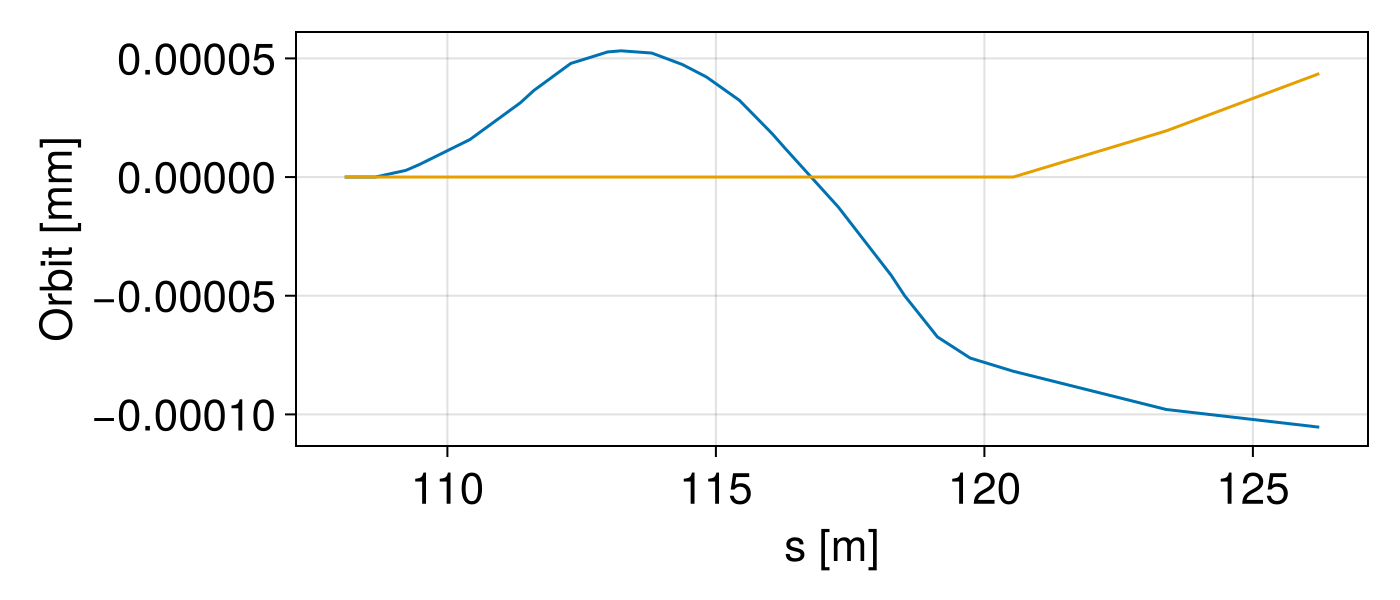

In [174]:
f = Figure(fontsize=22, size=(700,300));
ax = Axis(f[1, 1], xlabel="s [m]", ylabel="Orbit [mm]");
lines!(ax, s_downstream[s:e], (orbit_x - bmad_orbits[:,1])[s:e], label=L"x"); 
lines!(ax, s_downstream[s:e], (orbit_y - bmad_orbits[:,3])[s:e], label=L"y");
display(f);

In [46]:
tw = twiss(ring)

Twiss:
 coasting_beam = true
 tunes[1:3]    = [Qx, Qy, slip]
 table         has columns: beamline_index, name, s, phi_1, beta_1, alpha_1, phi_2, beta_2, alpha_2, phi_3, gamma_c, c11, c12, c21, c22, orbit_x, orbit_px, orbit_y, orbit_py, orbit_z, orbit_pz

In [47]:
tw.tunes

3-element StaticArraysCore.SVector{3, TPS64{GTPSA.Dynamic}}:
Descriptor(NV=6, MO=1)
INDEX  COEFFICIENT             ORDER   EXPONENTS
----------------------------------------------------
  1:   7.9992648880708200E-02    0     0 0  0 0  0 0
----------------------------------------------------
  2:   1.3995717398858212E-01    0     0 0  0 0  0 0
----------------------------------------------------
  3:   1.0906009414185502E-14    1     1 0  0 0  0 0
  3:   1.0906009414185502E-14    1     0 1  0 0  0 0
  3:   9.9664072084419302E-16    1     0 0  1 0  0 0
  3:   9.9664072084419302E-16    1     0 0  0 1  0 0
  3:  -2.3336911940380842E+00    1     0 0  0 0  0 1


In [101]:
ring.line[70].Kn0L=-1e-5

-1.0e-5

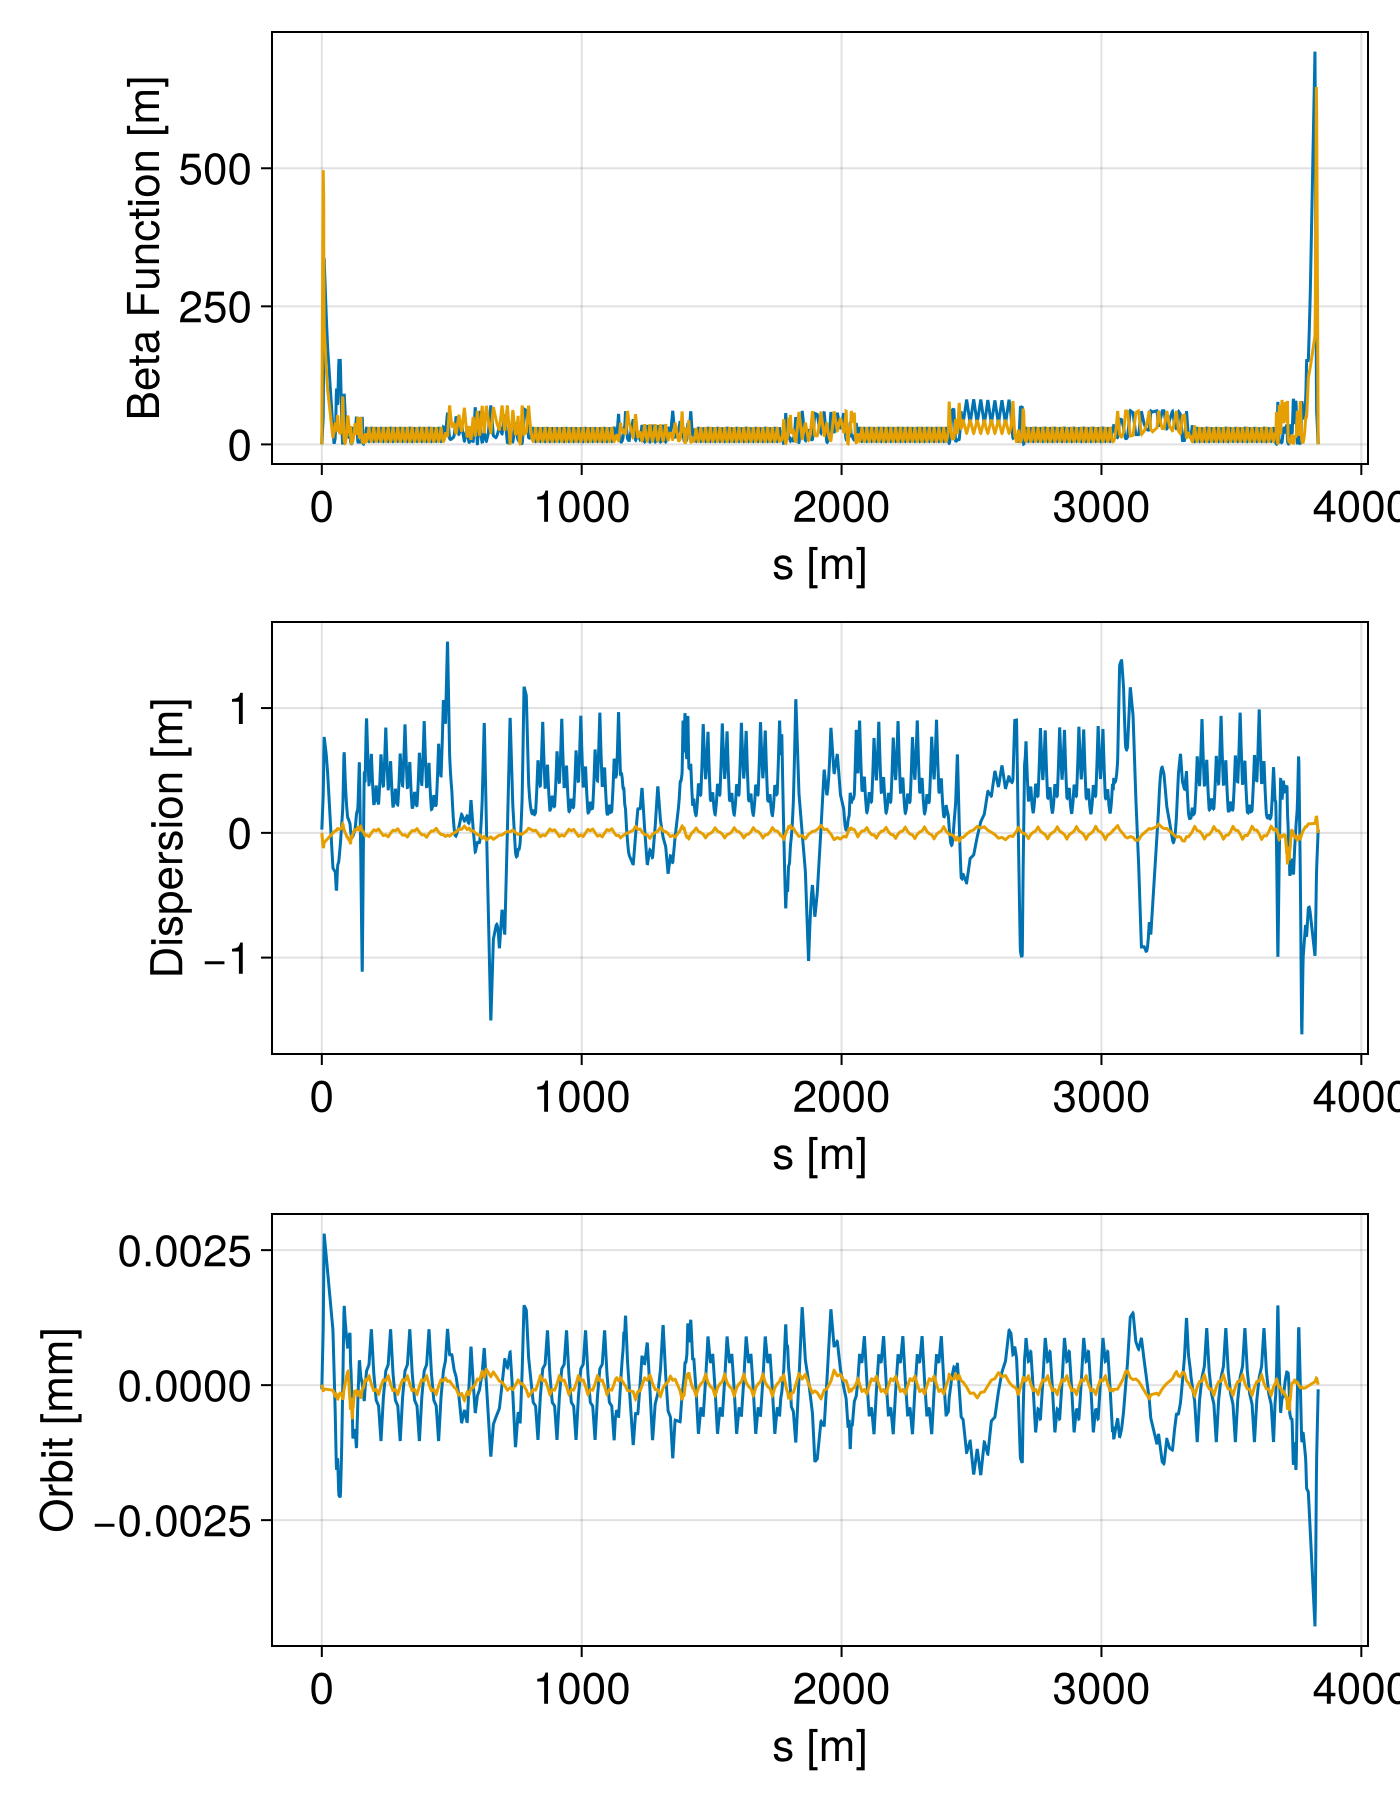

In [122]:
tw = twiss(ring)
t = tw.table

eta_1 = map(x->x[6], t.orbit_x)
eta_2 = map(x->x[6], t.orbit_y)

# Plot the betas, dispersion, orbit:
f = Figure(fontsize=22, size=(700,3*300));
ax1 = Axis(f[1, 1], xlabel="s [m]", ylabel="Beta Function [m]");
ax2 = Axis(f[2, 1], xlabel="s [m]", ylabel="Dispersion [m]");
ax3 = Axis(f[3, 1], xlabel="s [m]", ylabel="Orbit [mm]");

lines!(ax1, t.s, t.beta_1, label=L"\beta_1"); 
lines!(ax1, t.s, t.beta_2, label=L"\beta_2");
lines!(ax2, t.s, eta_1, label=L"\eta_x"); 
lines!(ax2, t.s, eta_2, label=L"\eta_y");
lines!(ax3, t.s, scalar.(t.orbit_x), label=L"x"); 
lines!(ax3, t.s, scalar.(t.orbit_y), label=L"y");

#axislegend(ax1, position=:rt);
##axislegend(ax2, position=:rt);
#axislegend(ax3, position=:rt);

display(f);

In [118]:
b0 = Bunch([scalar.([t.orbit_x[1], t.orbit_px[1], t.orbit_y[1], t.orbit_py[1]])..., 0, 0,]')

Bunch{Float64, Float64, BeamTracking.Coords{Vector{UInt8}, LinearAlgebra.Adjoint{Float64, Vector{Float64}}, Nothing, Nothing}}(Species(Null), NaN, 0.0, BeamTracking.Coords{Vector{UInt8}, LinearAlgebra.Adjoint{Float64, Vector{Float64}}, Nothing, Nothing}(UInt8[0x01], [-7.69420413519455e-5 0.00021113488484277465 … 0.0 0.0], nothing, nothing))

In [119]:
track!(b0, ring)

Setting bunch.species = Species(electron, charge=-1.0e, mass=510998.95069 eV/c², spin=0.5ħ) (reference species from the Beamline)
Setting bunch.p_over_q_ref = -59.5287244902766 (reference p_over_q_ref from the Beamline)


Bunch{Float64, Float64, BeamTracking.Coords{Vector{UInt8}, LinearAlgebra.Adjoint{Float64, Vector{Float64}}, Nothing, Nothing}}(Species(electron, charge=-1.0e, mass=510998.95069 eV/c², spin=0.5ħ), -59.5287244902766, 1.2788861294459976e-5, BeamTracking.Coords{Vector{UInt8}, LinearAlgebra.Adjoint{Float64, Vector{Float64}}, Nothing, Nothing}(UInt8[0x01], [-7.694204135187351e-5 0.00021113488484264737 … -6.520072006153137e-7 0.0], nothing, nothing))

In [121]:
[scalar.([t.orbit_x[1], t.orbit_px[1], t.orbit_y[1], t.orbit_py[1]])..., 0, 0,]'

1×6 adjoint(::Vector{Float64}) with eltype Float64:
 -7.6942e-5  0.000211135  8.35219e-6  -2.03969e-5  0.0  0.0

In [120]:
b0.coords.v

1×6 adjoint(::Vector{Float64}) with eltype Float64:
 -7.6942e-5  0.000211135  8.35219e-6  -2.03969e-5  -6.52007e-7  0.0

In [109]:
ring.line[70].Bn0L

0.000595287244902766

In [6]:
ring.line[70].Kn0L=1e-5

1.0e-5

In [11]:
ring.line[70].Bn0L

-0.000595287244902766

In [16]:
t.orbit_x[1]

TPS64{GTPSA.Dynamic}:
Descriptor(NV=6, MO=1)
 COEFFICIENT             ORDER   EXPONENTS
-2.7268718761099876E-03    1     0 0  0 0  0 1


In [14]:
find_closed_orbit(ring)

([4.315006515845546e-5 -7.729615181285615e-5 … 0.0 0.0], true)

In [45]:
find_closed_orbit(ring)

([4.281420506946533e-5 -7.663217076872542e-5 … 0.0 0.0], true)

In [22]:
b0 = Bunch(find_closed_orbit(ring)[1])

Bunch{Float64, Float64, BeamTracking.Coords{Vector{UInt8}, Matrix{Float64}, Nothing, Nothing}}(Species(Null), NaN, 0.0, BeamTracking.Coords{Vector{UInt8}, Matrix{Float64}, Nothing, Nothing}(UInt8[0x01], [4.315006515845546e-5 -7.729615181285615e-5 … 0.0 0.0], nothing, nothing))

In [23]:
track!(b0, ring)

Setting bunch.species = Species(electron, charge=-1.0e, mass=510998.95069 eV/c², spin=0.5ħ) (reference species from the Beamline)
Setting bunch.p_over_q_ref = -59.5287244902766 (reference p_over_q_ref from the Beamline)


Bunch{Float64, Float64, BeamTracking.Coords{Vector{UInt8}, Matrix{Float64}, Nothing, Nothing}}(Species(electron, charge=-1.0e, mass=510998.95069 eV/c², spin=0.5ħ), -59.5287244902766, 1.2788861294459976e-5, BeamTracking.Coords{Vector{UInt8}, Matrix{Float64}, Nothing, Nothing}(UInt8[0x01], [4.315006515854923e-5 -7.729615181316325e-5 … -7.006951102727768e-8 0.0], nothing, nothing))

In [24]:
b0.coords.v

1×6 Matrix{Float64}:
 4.31501e-5  -7.72962e-5  -9.30759e-6  4.29985e-6  -7.00695e-8  0.0

In [42]:
b0 = Bunch([0.3895242289768788E-04, 0.1089098278770884E-03, 0.4328223402530915E-05, -0.1197469920970387E-04, 0, 0]')

Bunch{Float64, Float64, BeamTracking.Coords{Vector{UInt8}, LinearAlgebra.Adjoint{Float64, Vector{Float64}}, Nothing, Nothing}}(Species(Null), NaN, 0.0, BeamTracking.Coords{Vector{UInt8}, LinearAlgebra.Adjoint{Float64, Vector{Float64}}, Nothing, Nothing}(UInt8[0x01], [3.895242289768788e-5 0.0001089098278770884 … 0.0 0.0], nothing, nothing))

In [43]:
track!(b0, ring)

Setting bunch.species = Species(electron, charge=-1.0e, mass=510998.95069 eV/c², spin=0.5ħ) (reference species from the Beamline)
Setting bunch.p_over_q_ref = -59.5287244902766 (reference p_over_q_ref from the Beamline)


Bunch{Float64, Float64, BeamTracking.Coords{Vector{UInt8}, LinearAlgebra.Adjoint{Float64, Vector{Float64}}, Nothing, Nothing}}(Species(electron, charge=-1.0e, mass=510998.95069 eV/c², spin=0.5ħ), -59.5287244902766, 1.2788861294459976e-5, BeamTracking.Coords{Vector{UInt8}, LinearAlgebra.Adjoint{Float64, Vector{Float64}}, Nothing, Nothing}(UInt8[0x01], [9.213107119873155e-5 8.912416870346844e-5 … 5.946605576716653e-7 0.0], nothing, nothing))

In [89]:
ring.line[70].tracking_method = Yoshida(order=4,num_steps=10)

Yoshida(4, 10, -1.0, false, false, BeamTracking.Fringe.BothEnds)

In [65]:
foreach(x->x.tracking_method=Yoshida(order=4,num_steps=10), ring.line)

In [44]:
b0.coords.v

1×6 adjoint(::Vector{Float64}) with eltype Float64:
 9.21311e-5  8.91242e-5  -1.31722e-6  -0.000190319  5.94661e-7  0.0

In [28]:
t.orbit_x[70]

TPS64{GTPSA.Dynamic}:
Descriptor(NV=6, MO=1)
 COEFFICIENT             ORDER   EXPONENTS
-2.5329395146341790E-04    0     0 0  0 0  0 0
-9.5483158067329339E-03    1     0 0  0 0  0 1


In [ ]:
using GTPSA
d = Descriptor(6,1)